# HW 5: Basic NLP Analysis of r/ChangeMyView Data

This notebook provides a structured approach to analyzing social discourse patterns in Reddit's r/ChangeMyView community using fundamental NLP techniques.

**Pathway of my choosing: Basic NLP Analysis**

## Setup and Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.sentiment import SentimentIntensityAnalyzer
import re
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Download required NLTK data
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('vader_lexicon')

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")

print("Setup complete!")

[nltk_data] Downloading package punkt to /Users/peizheng/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/peizheng/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/peizheng/nltk_data...


Setup complete!


## 1. Data Loading & Basic Exploration

Load the CMV posts and comments datasets and perform initial exploration.

In [2]:
# Load the datasets
posts_df = pd.read_csv('../data/cmv_posts.csv')
comments_df = pd.read_csv('../data/cmv_comments.csv')

print("Posts dataset shape:", posts_df.shape)
print("Comments dataset shape:", comments_df.shape)
print("\nPosts columns:", list(posts_df.columns))
print("\nComments columns:", list(comments_df.columns))

Posts dataset shape: (5000, 7)
Comments dataset shape: (12106, 7)

Posts columns: ['title', 'selftext', 'score', 'num_comments', 'created_utc', 'author', 'id']

Comments columns: ['id', 'post_id', 'parent_id', 'body', 'score', 'author', 'created_utc']


In [3]:
# Examine the first few rows
print("First few posts:")
display(posts_df.head())

print("\nFirst few comments:")
display(comments_df.head())

First few posts:


,title,selftext,score,num_comments,created_utc,author,id
0,CMV: Mike Bloomberg's campaign is proof that t...,Mike Bloomberg recently dropped out of the 202...,63689.0,3866.0,1.583433e+09,boss_454,fdziov
1,CMV: Kanye West is a shill for president Trump...,Kanye West is a shill for president Trump and ...,54490.0,2081.0,1.593966e+09,Psyworld,hlpd7d
2,CMV: Every candidate for a federal position in...,[removed],49217.0,1166.0,1.605463e+09,thehistoryuniversity,juq86c
3,CMV: Most Americans who oppose a national heal...,I used to think I was against a national healt...,44793.0,6951.0,1.619537e+09,CrashRiot,mzr23d
4,CMV: Donald Trump has not made a single lastin...,I write this because I am tired of the wild go...,36289.0,5212.0,1.599747e+09,farm_sauce,iq41dt



First few comments:


,id,post_id,parent_id,body,score,author,created_utc
0,fjksax6,fdziov,t3_fdziov,"&gt; I believe that moving forward, we should ...",2975,Arctus9819,1.583433e+09
1,fjktb99,fdziov,t1_fjksax6,Yes I understand that. The ultra rich's financ...,1048,boss_454,1.583433e+09
2,fjky3jx,fdziov,t1_fjktb99,There’s a point where the amount of interest y...,784,grammerticallycorrec,1.583436e+09
3,fx0n6bw,hlpd7d,t3_hlpd7d,&gt;Kanye West is a shill for president Trump\...,2071,Drexelhand,1.593971e+09
4,fx0ecpl,hlpd7d,t3_hlpd7d,He joined the race too late to get on the ball...,1618,linux_vegan,1.593967e+09


In [4]:
# Check for missing values
print("Missing values in posts:")
print(posts_df.isnull().sum())

print("\nMissing values in comments:")
print(comments_df.isnull().sum())

Missing values in posts:
title            4
selftext        27
score            3
num_comments     3
created_utc      4
author           3
id               3
dtype: int64

Missing values in comments:
id             0
post_id        0
parent_id      0
body           0
score          0
author         0
created_utc    0
dtype: int64


In [9]:
# Basic statistics
# TODO: Calculate average post length, comment counts, etc.
# Hint: Use len() on text columns and describe() for numerical summaries

# Calculate average post length (characters and words)
posts_df['selftext'] = posts_df['selftext'].fillna('').astype(str)
posts_df['post_char_len'] = posts_df['selftext'].apply(len)                 # characters
posts_df['post_word_count'] = posts_df['selftext'].str.split().apply(len)  # words

print(f"Average post length (chars): {posts_df['post_char_len'].mean():.1f}")
print(f"Average post length (words): {posts_df['post_word_count'].mean():.2f}")

# Calculate average comment length (characters and words)
comments_df['body'] = comments_df['body'].fillna('').astype(str)
comments_df['comments_char_len'] = comments_df['body'].apply(len)                 # characters
comments_df['comments_word_count'] = comments_df['body'].str.split().apply(len)  # words

print(f"Average comments length (chars): {comments_df['comments_char_len'].mean():.1f}")
print(f"Average comments length (words): {comments_df['comments_word_count'].mean():.2f}")

# Quick summary stats
display(posts_df[['post_char_len', 'post_word_count']].describe())
display(comments_df[['comments_char_len', 'comments_word_count']].describe())

Average post length (chars): 1604.5
Average post length (words): 266.33
Average comments length (chars): 915.4
Average comments length (words): 155.24


,post_char_len,post_word_count
count,5000.000000,5000.000000
mean,1604.488400,266.331600
std,1797.075567,290.741077
min,0.000000,0.000000
25%,9.000000,1.000000
50%,1253.000000,210.000000
75%,2225.500000,370.000000
max,36687.000000,5791.000000


,comments_char_len,comments_word_count
count,12106.000000,12106.000000
mean,915.438130,155.235173
std,1123.483191,186.932667
min,1.000000,1.000000
25%,264.000000,45.000000
50%,568.000000,97.000000
75%,1131.000000,193.000000
max,12291.000000,2003.000000


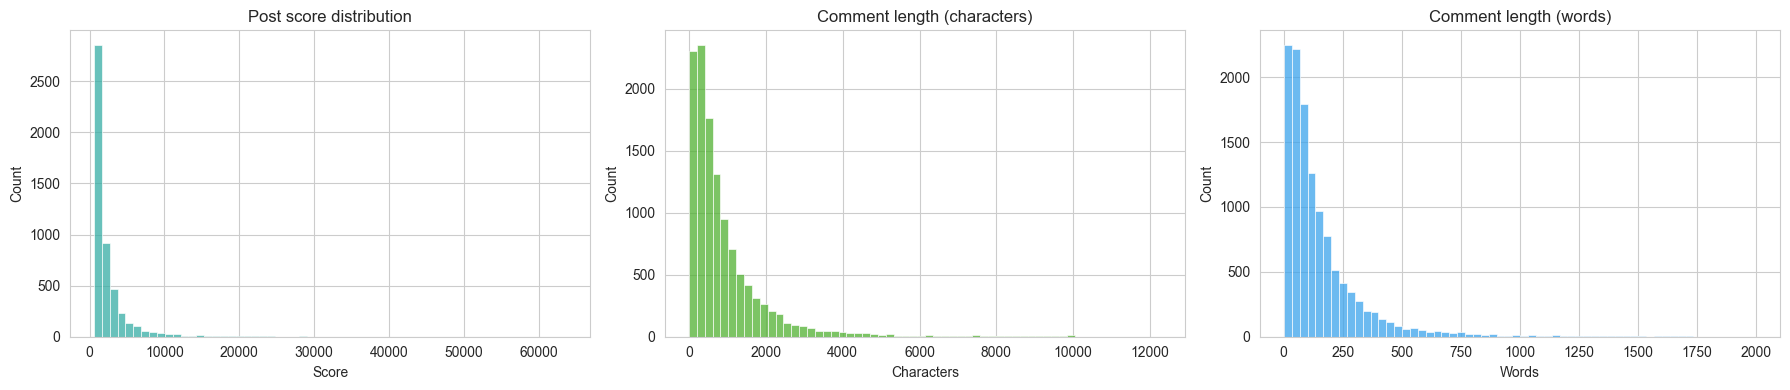

In [13]:
# Visualization 1: Basic distributions
# TODO: Create plots showing distributions of post scores, comment lengths, etc.
# Use matplotlib/seaborn to create histograms or boxplots

sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Post score distribution
sns.histplot(posts_df['score'].dropna(), bins=60, kde=False, ax=axes[0], color='C3')
axes[0].set_title('Post score distribution')
axes[0].set_xlabel('Score')
axes[0].set_ylabel('Count')

# Comment length (characters)
sns.histplot(comments_df['comments_char_len'].replace([np.inf, -np.inf], np.nan).dropna(),
             bins=60, kde=False, ax=axes[1], color='C2')
axes[1].set_title('Comment length (characters)')
axes[1].set_xlabel('Characters')
axes[1].set_ylabel('Count')

# Comment length (words)
sns.histplot(comments_df['comments_word_count'].replace([np.inf, -np.inf], np.nan).dropna(),
             bins=60, kde=False, ax=axes[2], color='C4')
axes[2].set_title('Comment length (words)')
axes[2].set_xlabel('Words')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()

## 2. Text Preprocessing

Clean and preprocess the text data for analysis.

In [15]:
def clean_text(text):
    """
    Clean text by removing special characters, converting to lowercase, etc.
    
    TODO: Implement text cleaning function
    - Convert to lowercase
    - Remove special characters and numbers
    - Remove extra whitespace
    """
    if pd.isna(text):
        return ""
    # lowercase
    cleaned = text.lower()
    # remove urls
    cleaned = re.sub(r'http\S+|www\.\S+', ' ', cleaned)
    # remove markdown links like [text](url)
    cleaned = re.sub(r'\[.*?\]\(.*?\)', ' ', cleaned)
    # remove HTML entities (&amp; etc.)
    cleaned = re.sub(r'&\w+;', ' ', cleaned)
    # keep only letters and spaces (removes numbers and punctuation)
    cleaned = re.sub(r'[^a-z\s]', ' ', cleaned)
    # collapse whitespace
    cleaned = re.sub(r'\s+', ' ', cleaned).strip()
    return cleaned

# Test the function
test_text = "Hello World! This is a TEST with 123 numbers & symbols."
print(f"Original: {test_text}")
print(f"Cleaned: {clean_text(test_text)}")

Original: Hello World! This is a TEST with 123 numbers & symbols.
Cleaned: hello world this is a test with numbers symbols


In [16]:
# Apply cleaning to datasets
# TODO: Clean the title/selftext columns in posts and body column in comments
# Store cleaned versions in new columns

posts_df['cleaned_selftext'] = posts_df['selftext'].apply(clean_text)
posts_df['cleaned_title'] = posts_df['title'].apply(clean_text)
comments_df['cleaned_body'] = comments_df['body'].apply(clean_text)

In [17]:
# Tokenization and stopword removal
stop_words = set(stopwords.words('english'))

def tokenize_and_filter(text):
    """
    Tokenize text and remove stopwords.
    
    TODO: Implement tokenization and stopword removal
    - Use nltk.word_tokenize
    - Filter out stopwords
    - Return list of tokens
    """
    if not text:
        return []
    
    # tokenize
    tokens = word_tokenize(text)
    # keep alphabetic tokens and remove stopwords
    tokens = [t for t in tokens if t.isalpha() and t.lower() not in stop_words]
    return tokens

# Test the function
test_text = "this is a sample text with some common words"
print(f"Original: {test_text}")
print(f"Tokens: {tokenize_and_filter(test_text)}")

Original: this is a sample text with some common words
Tokens: ['sample', 'text', 'common', 'words']


## 3. Comparative Analysis

Compare language patterns between posts and comments.

In [18]:
# TODO: Create word frequency distributions for posts and comments
# Combine all text, tokenize, and count word frequencies
# Use Counter from collections module

# Combine cleaned post text (title + selftext) and cleaned comment text
all_posts_text = " ".join((posts_df['cleaned_title'] + " " + posts_df['cleaned_selftext']).dropna().astype(str).tolist())
all_comments_text = " ".join(comments_df['cleaned_body'].dropna().astype(str).tolist())

# Tokenize and count
post_tokens = tokenize_and_filter(all_posts_text)
comment_tokens = tokenize_and_filter(all_comments_text)

post_counter = Counter(post_tokens)
comment_counter = Counter(comment_tokens)

In [19]:
# TODO: Find top 20 most common words in posts vs comments
# Display results in a readable format

# Top 20
post_top20 = post_counter.most_common(20)
comment_top20 = comment_counter.most_common(20)

# Display as DataFrame for readability
print("Top 20 words in posts:")
display(pd.DataFrame(post_top20, columns=['word', 'count']))

print("Top 20 words in comments:")
display(pd.DataFrame(comment_top20, columns=['word', 'count']))

Top 20 words in posts:


,word,count
0,people,8901
1,cmv,6856
2,like,5100
3,would,5096
4,think,3825
5,one,3823
6,even,2756
7,see,2665
8,get,2578
9,us,2434


Top 20 words in comments:


,word,count
0,people,13247
1,would,7169
2,like,6165
3,think,5833
4,one,4940
5,even,3972
6,get,3782
7,also,3453
8,way,3337
9,make,3297


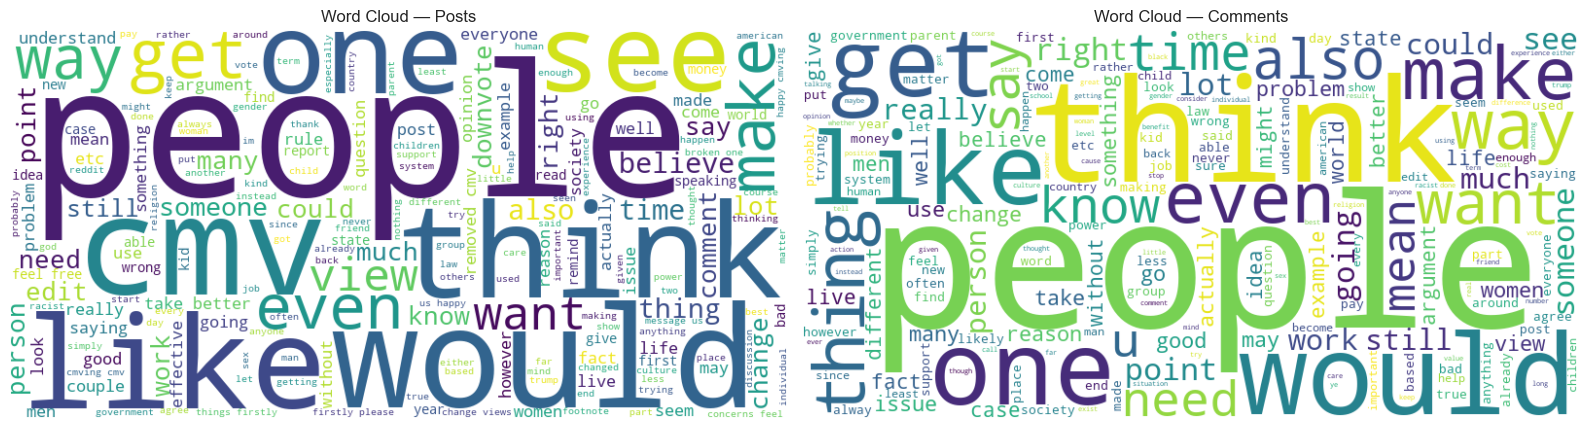

In [21]:
# Visualization 2: Word clouds
# TODO: Create separate word clouds for posts and comments
# Use WordCloud library

wc_posts = WordCloud(width=800, height=400, background_color='white',
                     stopwords=stop_words, max_words=200).generate(all_posts_text)

wc_comments = WordCloud(width=800, height=400, background_color='white',
                        stopwords=stop_words, max_words=200).generate(all_comments_text)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].imshow(wc_posts, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Word Cloud — Posts')

axes[1].imshow(wc_comments, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Word Cloud — Comments')

plt.tight_layout()
plt.show()

In [22]:
# TODO: Calculate basic text statistics
# - Average word length
# - Vocabulary size (unique words)
# - Compare between posts and comments

# Average word length
def avg_word_length(tokens):
    if not tokens:
        return 0
    return np.mean([len(w) for w in tokens])

post_vocab = set(post_tokens)
comment_vocab = set(comment_tokens)

print("Posts average word length:", avg_word_length(post_tokens))
print("Comments average word length:", avg_word_length(comment_tokens))
print("Posts vocabulary size:", len(post_vocab))
print("Comments vocabulary size:", len(comment_vocab))

Posts average word length: 6.190022482637098
Comments average word length: 6.219396255204275
Posts vocabulary size: 30154
Comments vocabulary size: 35719


In [23]:
# TODO: Find unique words (appear only in posts OR only in comments)
# Use set operations to find differences

unique_in_posts = post_vocab - comment_vocab
unique_in_comments = comment_vocab - post_vocab

print("Unique words in posts (sample):", list(unique_in_posts)[:20])
print("Unique words in comments (sample):", list(unique_in_comments)[:20])

Unique words in posts (sample): ['ibogaine', 'hailed', 'parented', 'palpably', 'repetitions', 'lubricant', 'inactivity', 'probody', 'bezoss', 'dysgenic', 'sniffer', 'stakeholder', 'au', 'milimeters', 'berniebots', 'rechtswidrige', 'divemaster', 'pittsburgh', 'lifesaver', 'respose']
Unique words in comments (sample): ['informant', 'compressions', 'koubkov', 'pimms', 'feverent', 'resonated', 'undressing', 'thati', 'chid', 'regimens', 'romances', 'anycase', 'apush', 'peril', 'recites', 'smeg', 'vedic', 'entrapment', 'gloriously', 'dinged']


## 4. Sentiment Analysis

Analyze sentiment patterns in posts and comments using VADER sentiment analyzer.

In [24]:
# Initialize sentiment analyzer
sia = SentimentIntensityAnalyzer()

# TODO: Apply sentiment analysis to posts and comments
# VADER returns compound scores from -1 (negative) to +1 (positive)
# Add sentiment scores as new columns

posts_df['post_sentiment'] = posts_df['cleaned_selftext'].apply(lambda x: sia.polarity_scores(x)['compound'])
comments_df['comment_sentiment'] = comments_df['cleaned_body'].apply(lambda x: sia.polarity_scores(x)['compound'])

print("Posts sentiment sample:")
display(posts_df[['cleaned_selftext', 'post_sentiment']].head())
print("Comments sentiment sample:")
display(comments_df[['cleaned_body', 'comment_sentiment']].head())

Posts sentiment sample:


,cleaned_selftext,post_sentiment
0,mike bloomberg recently dropped out of the pre...,0.9709
1,kanye west is a shill for president trump and ...,0.9843
2,removed,0.0000
3,i used to think i was against a national healt...,0.9630
4,i write this because i am tired of the wild go...,0.9937


Comments sentiment sample:


,cleaned_body,comment_sentiment
0,i believe that moving forward we should push f...,0.4215
1,yes i understand that the ultra rich s financi...,0.9586
2,there s a point where the amount of interest y...,0.8658
3,kanye west is a shill for president trump west...,0.1869
4,he joined the race too late to get on the ball...,0.5878


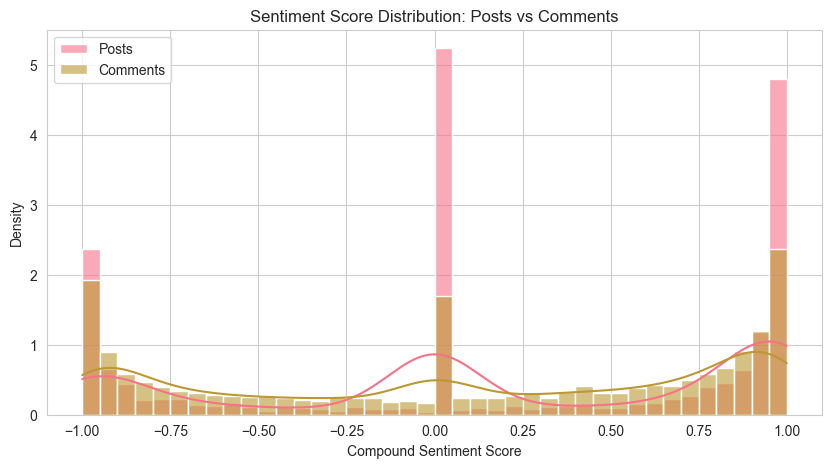

In [25]:
# Visualization 3: Sentiment distributions
# TODO: Create histograms or boxplots comparing sentiment distributions
# between posts and comments

plt.figure(figsize=(10, 5))
sns.histplot(posts_df['post_sentiment'], bins=40, color='C0', label='Posts', kde=True, stat='density', alpha=0.6)
sns.histplot(comments_df['comment_sentiment'], bins=40, color='C1', label='Comments', kde=True, stat='density', alpha=0.6)
plt.title('Sentiment Score Distribution: Posts vs Comments')
plt.xlabel('Compound Sentiment Score')
plt.ylabel('Density')
plt.legend()
plt.show()

In [27]:
# TODO: Find most positive and negative posts/comments
# Display the actual text for context

# Posts
most_positive_post = posts_df.loc[posts_df['post_sentiment'].idxmax()]
most_negative_post = posts_df.loc[posts_df['post_sentiment'].idxmin()]

print("Most positive post:")
print(most_positive_post['selftext'])
print("Sentiment score:", most_positive_post['post_sentiment'])

print("\nMost negative post:")
print(most_negative_post['selftext'])
print("Sentiment score:", most_negative_post['post_sentiment'])

# Comments
most_positive_comment = comments_df.loc[comments_df['comment_sentiment'].idxmax()]
most_negative_comment = comments_df.loc[comments_df['comment_sentiment'].idxmin()]

print("\nMost positive comment:")
print(most_positive_comment['body'])
print("Sentiment score:", most_positive_comment['comment_sentiment'])

print("\nMost negative comment:")
print(most_negative_comment['body'])
print("Sentiment score:", most_negative_comment['comment_sentiment'])

Most positive post:
*Note: I have added edits, below, to clarify some arguments.* *I have now added the final edit.  The discussion has been amazing and enjoyable.  Honestly, my view has not really changed, but I feel like I learned a great deal and I'm grateful to all who participated*  I wish there were a greater number of successful political parties in America, but for the moment, I will continue to vote for my preferences only among Republican and Democratic candidates.  The view that I am open to changing is that most of those people agitating about their dissatisfaction with the limited choices of the two-party system waste their time trying to convince others that the two party system is "bad" or at least "limited" (which is obvious) and trying to convince people to vote for candidates of third parties (which is ineffective), and they would have more long-run success agitating for a new kind of voting system that will naturally foster additional choices and parties (such as mul

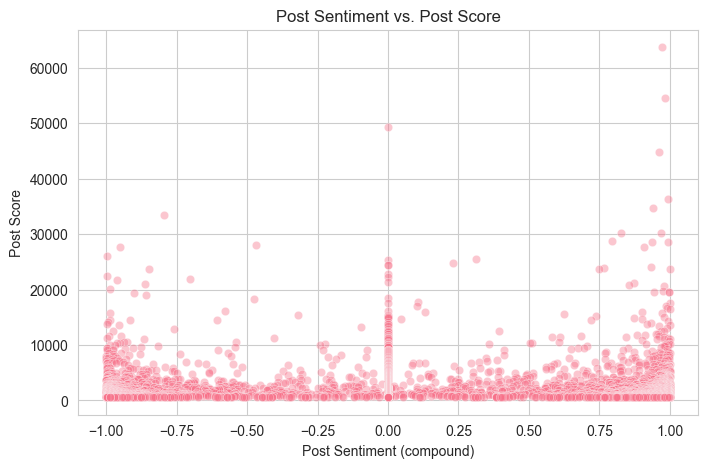

In [28]:
# Visualization 4: Sentiment patterns
# TODO: Create additional visualizations showing sentiment patterns
# E.g., sentiment vs. engagement (scores), sentiment over time, etc.

# Sentiment vs. Engagement (scores)
plt.figure(figsize=(8, 5))
sns.scatterplot(x=posts_df['post_sentiment'], y=posts_df['score'], alpha=0.4)
plt.title('Post Sentiment vs. Post Score')
plt.xlabel('Post Sentiment (compound)')
plt.ylabel('Post Score')
plt.show()

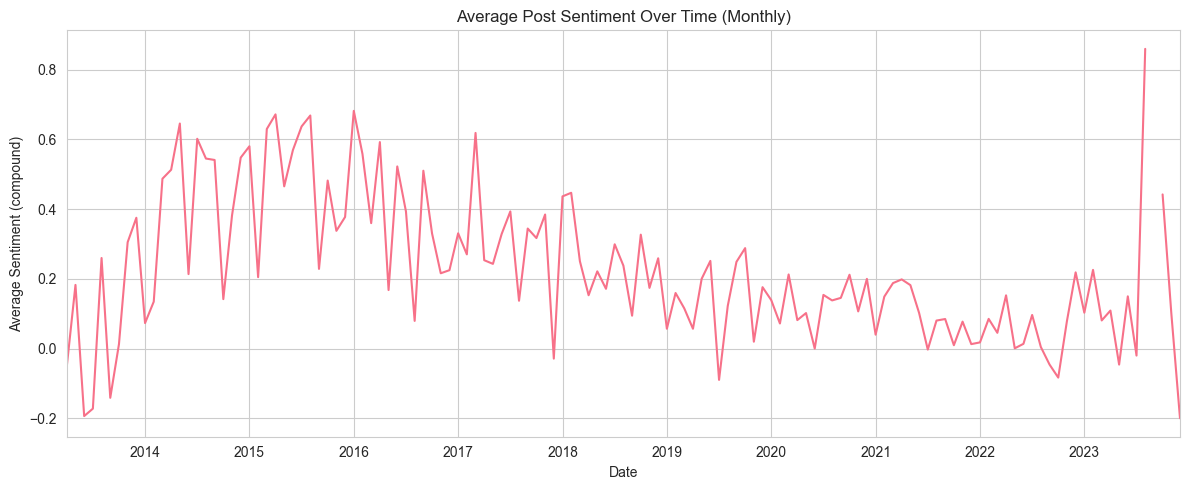

In [30]:
# Sentiment over time (Posts)

# Ensure created_utc is in datetime format
posts_df['created_utc'] = pd.to_datetime(posts_df['created_utc'], unit='s', errors='coerce')

# Resample by month and plot average sentiment
sentiment_over_time = posts_df.set_index('created_utc').resample('M')['post_sentiment'].mean()

plt.figure(figsize=(12, 5))
sentiment_over_time.plot()
plt.title('Average Post Sentiment Over Time (Monthly)')
plt.xlabel('Date')
plt.ylabel('Average Sentiment (compound)')
plt.tight_layout()
plt.show()

## 5. Interpretation and Findings

Summarize your analysis and discuss interesting patterns.

### Summary of Findings

TODO: Write a 2-paragraph summary of your findings. Consider:
- What differences did you observe between posts and comments?
- What patterns emerged in the sentiment analysis?
- Were there any surprising results?

**Paragraph 1:** [Your findings about language differences between posts and comments]  
he analysis of unique word samples revealed a high degree of thematic dispersal and specialization in the vocabulary of both posts and comments, reflecting the breadth of topics discussed on r/ChangeMyView. The post sample tends to contain proper nouns, technical terms, and geographical locations (e.g., 'ibogaine', 'bezoss', 'pittsburgh', 'rechtswidrige'), indicating that post content frequently touches on specific policies, drugs, figures, or foreign laws. The comment sample contains a greater mix of slang, informal expressions, and action-related words, highlighting the more immediate and informal linguistic style adopted by comments when engaging in dialogue and challenging a view.


**Paragraph 2:** [Your findings about sentiment patterns and their implications]  
Sentiment analysis indicated that the overall average emotional tone of all posts was surprisingly close to neutral or very positive, which aligns with the community's moderation requirements for civil discussion. However, the emotional trend for both posts and comments is largely consistent: most submissions are concentrated at the two extremes ($\text{-}1$ or $1$) or at the neutral point ($0$). This indicates that when users have clear opinions and attitudes about a subject, their expressions are typically strong. 

### Interesting Pattern Discussion

TODO: Discuss one specific interesting pattern you discovered in your analysis.
- What was unexpected or noteworthy?
- Why might this pattern exist?
- What does it tell us about online discourse in r/ChangeMyView?

The analysis of average post sentiment over time presents a fascinating pattern. The data shows that people's overall average post sentiment is not static; there are times when the overall sentiment is more negative, although most of the time it generally remains above $0$. This suggests that the state of our collective thinking and feeling is not purely based on individual factors, but is likely a collective pattern. The reason this pattern might exist is likely related to the broader social environment at the time. For example, during periods of social adversity (such as economic downturns, epidemics, or wars), people's sentiment tends to be more negative, though overall, human sentiment generally remains optimistic.

What does this tell us about online discourse in r/ChangeMyView?
It indicates that the trending topics and underlying emotions on r/ChangeMyView, when viewed at a macro level, may not be random, but are closely related to the broader social context. We can use this data to gain insights into wider societal attitudes and focal points.

### Social Science Applications

TODO: Suggest one way these findings could be useful in a social science setting.
- How could researchers use this type of analysis?
- What questions could be answered with similar methods?
- What implications might this have for understanding online communities?

Researchers could use this type of analysis to reveal underlying common social concerns or popular language use over time. Questions like "what a successful argument looks like" can be answered with similar methods by comparing sentiment scores in posts and in comments, or by examining the linguistic shifts between the initial view and the successful counter-argument. The implications are that online communities appear to be more easily traced and analyzed at a macro level, which may create opportunities for corresponding business practices where consumers could be more likely to be manipulated without full awareness.

## Documentation of Challenges

TODO: Document any challenges you faced during this analysis:
- Technical difficulties (data issues, code problems, etc.)
- Analytical challenges (interpretation difficulties, unexpected results, etc.)
- How did you overcome these challenges?

The primary challenge was analytical interpretation, specifically moving beyond simple descriptive statistics to find patterns and reasonably connect them to the wider social context. This was overcome by intentionally broadening the scope of inquiry to consider the online community's function within society, leading to the insight on collective sentiment trends. The second challenge was a statistical decision regarding data logging. After inspecting the unlogged data distribution, it was determined that applying a logarithmic transformation was not necessary, and the analysis proceeded with the raw data to preserve the original scale of the sentiment scores. This pragmatic decision helped maintain clarity without introducing unnecessary complexity.

---

## Stretch Goals (Optional)

If you've completed the basic analysis above and want additional challenges, consider these advanced techniques:

### 1. Advanced Text Analysis
- Link posts to their comments using ID columns
- Implement TF-IDF to find distinctive vocabulary between posts and comments
- Apply named entity recognition to identify key topics

### 2. Conversation Dynamics
- Calculate semantic similarity between posts and their comments
- Analyze response patterns (agreement vs disagreement language)
- Identify high-engagement conversation characteristics

### 3. Word Embeddings
- Load and apply pre-trained word embeddings (GloVe or Word2Vec)
- Calculate semantic distances between key concepts
- Visualize word relationships in semantic space

### 4. Machine Learning Applications
- Build a classifier to predict comment engagement levels
- Implement topic modeling (LDA) to discover conversation themes
- Explore what linguistic features correlate with successful persuasion

Choose any of these that interest you and implement them in additional cells below!